In [1]:
!pip install deepface -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.9 MB/s eta 0:00:00


Faces detected: 1


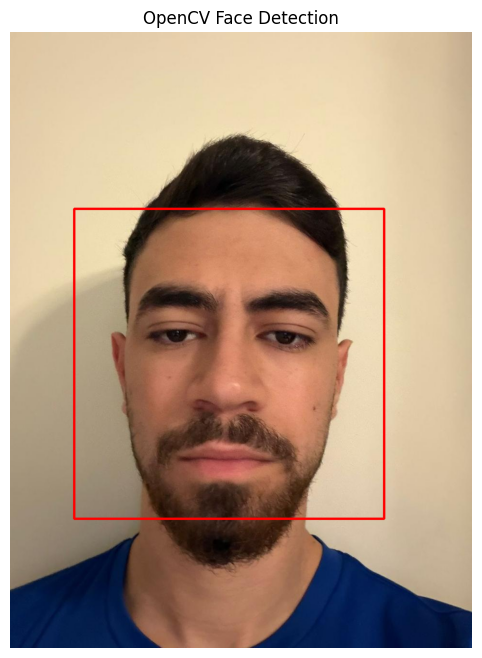

True

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("face_image.jpeg")

# OpenCV loads images in BGR order (not RGB) - convert for correct color display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load a pre-trained face detector (comes bundled with OpenCV)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Convert to grayscale - face detection works on brightness patterns, not color
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces - returns a list of (x, y, width, height) boxes
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print(f"Faces detected: {len(faces)}")

# Draw a rectangle around each detected face
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("OpenCV Face Detection")
plt.show()

# Save the output image
cv2.imwrite("face_detected_output.jpg", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

In [3]:
from deepface import DeepFace

result = DeepFace.analyze(img_path="face_image.jpeg", actions=["age", "gender", "emotion"])

# DeepFace returns a list (one entry per detected face)
analysis = result[0]
print(f"Predicted Age: {analysis['age']}")
print(f"Predicted Gender: {analysis['dominant_gender']}")
print(f"Predicted Emotion: {analysis['dominant_emotion']}")
print()
print("Full emotion breakdown:")
for emotion, score in analysis['emotion'].items():
    print(f"  {emotion}: {score:.2f}%")

26-06-20 20:15:16 - Directory /root/.deepface has been created
26-06-20 20:15:16 - Directory /root/.deepface/weights has been created


Action: age:   0%|          | 0/3 [00:00<?, ?it/s]    

26-06-20 20:15:20 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 9.96M/539M [00:00<00:05, 96.4MB/s]
  7%|▋         | 35.1M/539M [00:00<00:02, 186MB/s] 
 11%|█▏        | 61.3M/539M [00:00<00:02, 220MB/s]
 16%|█▌        | 84.4M/539M [00:00<00:02, 201MB/s]
 19%|█▉        | 105M/539M [00:00<00:02, 199MB/s] 
 23%|██▎       | 125M/539M [00:00<00:02, 184MB/s]
 27%|██▋       | 146M/539M [00:00<00:02, 189MB/s]
 31%|███       | 166M/539M [00:00<00:01, 193MB/s]
 35%|███▍      | 187M/539M [00:00<00:01, 197MB/s]
 39%|███▊      | 208M/539M [00:01<00:01, 199MB/s]
 42%|████▏     | 228M/539M [00:01<00:01, 197MB/s]
 46%|████▌     | 249M/539M [00:01<00:01, 200MB/s]
 50%|█████     | 269M/539M [00:01<00:01, 185MB/s]
 54%|█████▍    | 290M/539M [00:01<00:01, 191MB/s]
 58%|█████▊    | 311M/539M [00:01<00:01, 195MB/s]
 62%|██████▏   | 332M/539M [00:01<00:01, 

26-06-20 20:15:32 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 8.91M/537M [00:00<00:05, 89.0MB/s]
  5%|▍         | 25.7M/537M [00:00<00:03, 135MB/s] 
  8%|▊         | 43.0M/537M [00:00<00:03, 151MB/s]
 11%|█▏        | 61.3M/537M [00:00<00:02, 162MB/s]
 15%|█▍        | 79.7M/537M [00:00<00:02, 166MB/s]
 18%|█▊        | 96.5M/537M [00:00<00:02, 155MB/s]
 21%|██        | 113M/537M [00:00<00:02, 156MB/s] 
 24%|██▍       | 128M/537M [00:00<00:02, 151MB/s]
 27%|██▋       | 144M/537M [00:00<00:02, 152MB/s]
 30%|██▉       | 160M/537M [00:01<00:03, 108MB/s]
 32%|███▏      | 172M/537M [00:01<00:03, 102MB/s]
 35%|███▌      | 188M/537M [00:01<00:03, 114MB/s]
 38%|███▊      | 203M/537M [00:01<00:02, 123MB/s]
 41%|████      | 220M/537M [00:01<00:02, 132MB/s]
 44%|████▍     | 235M/537M [00:01<00:02, 138MB/s]
 47%|████▋     | 250M/537M [00:01

26-06-20 20:15:45 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...



100%|██████████| 5.98M/5.98M [00:00<00:00, 81.5MB/s]
Action: emotion: 100%|██████████| 3/3 [00:27<00:00,  9.27s/it]

Predicted Age: 32
Predicted Gender: Man
Predicted Emotion: neutral

Full emotion breakdown:
  angry: 8.89%
  disgust: 0.16%
  fear: 9.84%
  happy: 0.02%
  sad: 36.39%
  surprise: 0.00%
  neutral: 44.71%
